##  3D Prostate MRI Segmentation using MONAI and 3D U-Net

In [1]:
import os

In [2]:
file_path=r"C:\Users\HP PC\Downloads\Task05_Prostate"
os.listdir(file_path)

['archive (16).zip', 'dataset.json', 'imagesTr', 'imagesTs', 'labelsTr']

In [3]:
import os
from glob import glob

# Dataset path
file_path = r"C:\Users\HP PC\Downloads\Task05_Prostate"

# Check dataset structure
print(os.listdir(file_path))

['archive (16).zip', 'dataset.json', 'imagesTr', 'imagesTs', 'labelsTr']


In [4]:
import os

# Base dataset path
file_path = r"C:\Users\HP PC\Downloads\Task05_Prostate"

# Define folders
imagesTr = os.path.join(file_path, "imagesTr")
labelsTr = os.path.join(file_path, "labelsTr")

print("Paths defined successfully.")

Paths defined successfully.


### Inspect Folder Contents Directly

Run this carefully:

In [5]:
print("imagesTr contents:")
print(os.listdir(imagesTr)[:10])

print("\nlabelsTr contents:")
print(os.listdir(labelsTr)[:10])

imagesTr contents:
['prostate_00_0000.nii.gz', 'prostate_00_0001.nii.gz', 'prostate_01_0000.nii.gz', 'prostate_01_0001.nii.gz', 'prostate_02_0000.nii.gz', 'prostate_02_0001.nii.gz', 'prostate_04_0000.nii.gz', 'prostate_04_0001.nii.gz', 'prostate_06_0000.nii.gz', 'prostate_06_0001.nii.gz']

labelsTr contents:
['prostate_00.nii.gz', 'prostate_01.nii.gz', 'prostate_02.nii.gz', 'prostate_04.nii.gz', 'prostate_06.nii.gz', 'prostate_07.nii.gz', 'prostate_10.nii.gz', 'prostate_13.nii.gz', 'prostate_14.nii.gz', 'prostate_16.nii.gz']


### Inspect Training Images and Labels

Now verify:

number of MRI scans,
number of masks,
filename consistency.

In [6]:
from glob import glob
import os

imagesTr = os.path.join(file_path, "imagesTr")
labelsTr = os.path.join(file_path, "labelsTr")

train_images = sorted(
    glob(os.path.join(imagesTr, "*.nii.gz"))
)

train_labels = sorted(
    glob(os.path.join(labelsTr, "*.nii.gz"))
)

print("Number of Training Images:", len(train_images))
print("Number of Training Labels:", len(train_labels))

print("\nSample Image:")
print(train_images[0])

print("\nSample Label:")
print(train_labels[0])

Number of Training Images: 64
Number of Training Labels: 32

Sample Image:
C:\Users\HP PC\Downloads\Task05_Prostate\imagesTr\prostate_00_0000.nii.gz

Sample Label:
C:\Users\HP PC\Downloads\Task05_Prostate\labelsTr\prostate_00.nii.gz


### Preparing the dataset for nnU-Net

### Create Folders Automatically

In [7]:
import os

nnunet_base = r"C:\nnUNet_raw\Dataset005_Prostate"

imagesTr_out = os.path.join(nnunet_base, "imagesTr")
labelsTr_out = os.path.join(nnunet_base, "labelsTr")
imagesTs_out = os.path.join(nnunet_base, "imagesTs")

os.makedirs(imagesTr_out, exist_ok=True)
os.makedirs(labelsTr_out, exist_ok=True)
os.makedirs(imagesTs_out, exist_ok=True)

print("nnU-Net folder structure created successfully.")

nnU-Net folder structure created successfully.


In [8]:
import nibabel as nib

print("NiBabel version:", nib.__version__)

NiBabel version: 5.3.2


### Convert Training Images to nnU-Net Format

In [9]:
import os
import nibabel as nib
from glob import glob

# Original dataset folders
imagesTr = os.path.join(file_path, "imagesTr")
labelsTr = os.path.join(file_path, "labelsTr")

# nnU-Net output folders
nnunet_base = r"C:\nnUNet_raw\Dataset005_Prostate"

imagesTr_out = os.path.join(nnunet_base, "imagesTr")
labelsTr_out = os.path.join(nnunet_base, "labelsTr")

# Get image paths
train_images = sorted(glob(os.path.join(imagesTr, "*.nii")))

print("Total training images:", len(train_images))

# Convert images
for img_path in train_images:

    img = nib.load(img_path)

    base_name = os.path.basename(img_path).replace(".nii", "")

    new_name = f"{base_name}_0000.nii.gz"

    save_path = os.path.join(imagesTr_out, new_name)

    nib.save(img, save_path)

print("\nTraining image conversion completed successfully.")

Total training images: 0

Training image conversion completed successfully.


### Convert Labels

In [10]:
train_labels = sorted(glob(os.path.join(labelsTr, "*.nii")))

print("Total training labels:", len(train_labels))

# Convert labels
for lbl_path in train_labels:

    lbl = nib.load(lbl_path)

    base_name = os.path.basename(lbl_path).replace(".nii", "")

    new_name = f"{base_name}.nii.gz"

    save_path = os.path.join(labelsTr_out, new_name)

    nib.save(lbl, save_path)

print("\nTraining label conversion completed successfully.")

Total training labels: 0

Training label conversion completed successfully.


### Verify Converted Files

In [11]:
print("Converted training images:")
print(os.listdir(imagesTr_out)[:5])

print("\nConverted training labels:")
print(os.listdir(labelsTr_out)[:5])

Converted training images:
['prostate_00_0000.nii.gz', 'prostate_01_0000.nii.gz', 'prostate_02_0000.nii.gz', 'prostate_04_0000.nii.gz', 'prostate_06_0000.nii.gz']

Converted training labels:
['prostate_00.nii.gz', 'prostate_01.nii.gz', 'prostate_02.nii.gz', 'prostate_04.nii.gz', 'prostate_06.nii.gz']


### Next Stage — Create dataset.json

This file is extremely important.

It tells nnU-Net:

* what the MRI modality is,
* what each label means,
* dataset metadata,
* channel definitions.

Without this file nnU-Net cannot interpret the dataset properly.

### Create dataset.json

In [12]:
import json

dataset_json = {
    "channel_names": {
        "0": "MRI"
    },
    "labels": {
        "background": 0,
        "TZ": 1,
        "PZ": 2
    },
    "numTraining": 32,
    "file_ending": ".nii.gz"
}

json_path = os.path.join(nnunet_base, "dataset.json")

with open(json_path, "w") as f:
    json.dump(dataset_json, f, indent=4)

print("dataset.json created successfully.")

dataset.json created successfully.


In [13]:
import os
import nibabel as nib

# Base dataset path
file_path = r"C:\Users\HP PC\Downloads\Task05_Prostate"

# imagesTr folder
imagesTr = os.path.join(file_path, "imagesTr")

# Get first image file
sample_image = os.path.join(imagesTr, os.listdir(imagesTr)[0])

print("Sample image path:")
print(sample_image)

Sample image path:
C:\Users\HP PC\Downloads\Task05_Prostate\imagesTr\prostate_00_0000.nii.gz


###  INSPECT THE SHAPE AND MODALITY

In [14]:
img = nib.load(sample_image)
data = img.get_fdata()

print(data.shape)

(320, 320, 15)


### the complete modality-correction pipeline

that transformed your dataset from:

(320,320,15,2)

into proper nnU-Net multi-modal format.

This should absolutely exist in your LOCAL notebook permanently.

WHY THIS PROCESS WAS NECESSARY

Originally each MRI file contained:

(320,320,15,2)

Meaning:

* 15 MRI slices,
* 2 MRI modalities/channels stored together.



But nnU-Net expects:

separate files for each modality.

Example:

Correct nnU-Net Format
* prostate_00_0000.nii.gz
* prostate_00_0001.nii.gz

###  LET US DO THE MODALITY CORRECTION  STEP BY STEP BECAUSE ITS VERY IMPORTANT

### Import Libraries

In [15]:
import os
import nibabel as nib
import numpy as np
from glob import glob

### Define Dataset Paths

In [16]:
# Base dataset path
file_path = r"C:\Users\HP PC\Downloads\Task05_Prostate"

# nnU-Net imagesTr folder
imagesTr_path = os.path.join(file_path, "imagesTr")

print(imagesTr_path)

C:\Users\HP PC\Downloads\Task05_Prostate\imagesTr


### Inspect One MRI File

VERY important diagnostic step.

In [17]:
# Get one sample image
sample_image = os.path.join(imagesTr_path,
                            os.listdir(imagesTr_path)[0])

# Load MRI
img = nib.load(sample_image)

# Extract voxel data
data = img.get_fdata()

# Print shape
print("MRI shape:", data.shape)

MRI shape: (320, 320, 15)


### WHY THIS STEP MATTERS

This reveals:

the hidden modality structure.

Without this discovery:

* nnU-Net preprocessing fails,
* modality mismatch occurs,
* segmentation quality suffers.

This was one of your biggest breakthroughs.

### Get All MRI Files

In [18]:
image_files = sorted(
    glob(os.path.join(imagesTr_path, "*.nii"))
)

print("Total files:", len(image_files))

Total files: 0


### MODALITY SPLITTING (CRITICAL STEP)

This is the core correction process.

In [19]:
for img_path in image_files:

    # Load MRI
    img = nib.load(img_path)

    # Extract voxel data
    data = img.get_fdata()

    # Get filename without extension
    base_name = os.path.basename(img_path).replace(".nii", "")

    # Separate modalities
    modality_0 = data[:, :, :, 0]
    modality_1 = data[:, :, :, 1]

    # Create NIfTI objects
    mod0_img = nib.Nifti1Image(
        modality_0,
        img.affine,
        img.header
    )

    mod1_img = nib.Nifti1Image(
        modality_1,
        img.affine,
        img.header
    )

    # Save modality 0
    nib.save(
        mod0_img,
        os.path.join(
            imagesTr_path,
            f"{base_name}_0000.nii.gz"
        )
    )

    # Save modality 1
    nib.save(
        mod1_img,
        os.path.join(
            imagesTr_path,
            f"{base_name}_0001.nii.gz"
        )
    )

print("Modalities split successfully.")

Modalities split successfully.


### Verify Results

In [20]:
print(os.listdir(imagesTr_path)[:10])

['prostate_00_0000.nii.gz', 'prostate_00_0001.nii.gz', 'prostate_01_0000.nii.gz', 'prostate_01_0001.nii.gz', 'prostate_02_0000.nii.gz', 'prostate_02_0001.nii.gz', 'prostate_04_0000.nii.gz', 'prostate_04_0001.nii.gz', 'prostate_06_0000.nii.gz', 'prostate_06_0001.nii.gz']


### Correct Cleanup Code to remove prostate_00.nii the old file

In [21]:
import os
from glob import glob

# Find all original .nii files
old_files = glob(os.path.join(imagesTr_path, "*.nii"))

print("Files to remove:", len(old_files))

# Delete them
for f in old_files:
    os.remove(f)

print("Old combined modality files removed.")

Files to remove: 0
Old combined modality files removed.


### THEN Verify Again

In [22]:
print(os.listdir(imagesTr_path)[:10])

['prostate_00_0000.nii.gz', 'prostate_00_0001.nii.gz', 'prostate_01_0000.nii.gz', 'prostate_01_0001.nii.gz', 'prostate_02_0000.nii.gz', 'prostate_02_0001.nii.gz', 'prostate_04_0000.nii.gz', 'prostate_04_0001.nii.gz', 'prostate_06_0000.nii.gz', 'prostate_06_0001.nii.gz']


### Before Training though dataset is ready we must verify the following 

### VERIFY LABEL FILES

Check that labels are still correct.

In [23]:
print(os.listdir(labelsTr)[:20])

['prostate_00.nii.gz', 'prostate_01.nii.gz', 'prostate_02.nii.gz', 'prostate_04.nii.gz', 'prostate_06.nii.gz', 'prostate_07.nii.gz', 'prostate_10.nii.gz', 'prostate_13.nii.gz', 'prostate_14.nii.gz', 'prostate_16.nii.gz', 'prostate_17.nii.gz', 'prostate_18.nii.gz', 'prostate_20.nii.gz', 'prostate_21.nii.gz', 'prostate_24.nii.gz', 'prostate_25.nii.gz', 'prostate_28.nii.gz', 'prostate_29.nii.gz', 'prostate_31.nii.gz', 'prostate_32.nii.gz']


### CORRECT LABEL CONVERSION PROCESS

### Import Libraries

In [24]:
import os
import nibabel as nib
from glob import glob

### Define labelsTr Path

In [25]:
file_path = r"C:\Users\HP PC\Downloads\Task05_Prostate"

labelsTr = os.path.join(file_path, "labelsTr")

print(labelsTr)

C:\Users\HP PC\Downloads\Task05_Prostate\labelsTr


### Get All Label Files

In [26]:
label_files = sorted(
    glob(os.path.join(labelsTr, "*.nii"))
)

print("Total label files:", len(label_files))

Total label files: 0


### Convert .nii → .nii.gz

In [27]:
for lbl_path in label_files:

    # Load label
    lbl = nib.load(lbl_path)

    # Get filename
    base_name = os.path.basename(lbl_path).replace(".nii", "")

    # Save compressed version
    nib.save(
        lbl,
        os.path.join(labelsTr, f"{base_name}.nii.gz")
    )

print("Label conversion completed successfully.")

Label conversion completed successfully.


### VERIFY RESULTS

In [28]:
print(os.listdir(labelsTr)[:20])

['prostate_00.nii.gz', 'prostate_01.nii.gz', 'prostate_02.nii.gz', 'prostate_04.nii.gz', 'prostate_06.nii.gz', 'prostate_07.nii.gz', 'prostate_10.nii.gz', 'prostate_13.nii.gz', 'prostate_14.nii.gz', 'prostate_16.nii.gz', 'prostate_17.nii.gz', 'prostate_18.nii.gz', 'prostate_20.nii.gz', 'prostate_21.nii.gz', 'prostate_24.nii.gz', 'prostate_25.nii.gz', 'prostate_28.nii.gz', 'prostate_29.nii.gz', 'prostate_31.nii.gz', 'prostate_32.nii.gz']


### FINAL CLEANUP CODE REMOVE OLD .nii

In [29]:
from glob import glob
import os

# Find old .nii label files
old_label_files = glob(os.path.join(labelsTr, "*.nii"))

print("Old label files found:", len(old_label_files))

# Remove them
for f in old_label_files:
    os.remove(f)

print("Old .nii label files removed successfully.")

Old label files found: 0
Old .nii label files removed successfully.


### THEN VERIFY AGAIN

In [30]:
print(os.listdir(labelsTr)[:20])

['prostate_00.nii.gz', 'prostate_01.nii.gz', 'prostate_02.nii.gz', 'prostate_04.nii.gz', 'prostate_06.nii.gz', 'prostate_07.nii.gz', 'prostate_10.nii.gz', 'prostate_13.nii.gz', 'prostate_14.nii.gz', 'prostate_16.nii.gz', 'prostate_17.nii.gz', 'prostate_18.nii.gz', 'prostate_20.nii.gz', 'prostate_21.nii.gz', 'prostate_24.nii.gz', 'prostate_25.nii.gz', 'prostate_28.nii.gz', 'prostate_29.nii.gz', 'prostate_31.nii.gz', 'prostate_32.nii.gz']


### VERIFY IMAGE COUNT

In [31]:
from glob import glob
import os

mod0 = glob(os.path.join(imagesTr_path, "*_0000.nii.gz"))
mod1 = glob(os.path.join(imagesTr_path, "*_0001.nii.gz"))
labels = glob(os.path.join(labelsTr, "*.nii.gz"))

print("Modality 0:", len(mod0))
print("Modality 1:", len(mod1))
print("Labels:", len(labels))

Modality 0: 32
Modality 1: 32
Labels: 32


In [32]:
import nibabel as nib
import os

sample_mod0 = mod0[0]
sample_mod1 = mod1[0]

img0 = nib.load(sample_mod0)
img1 = nib.load(sample_mod1)

print("Modality 0 shape:", img0.shape)
print("Modality 1 shape:", img1.shape)

Modality 0 shape: (320, 320, 15)
Modality 1 shape: (320, 320, 15)


In [33]:
import os

print(os.listdir())

['.git', '.gitignore', '.ipynb_checkpoints', 'attention_unet_checkpoint_epoch10.pth', 'attention_unet_epoch10.pth', 'attention_unet_final_history.csv', 'attention_unet_finetuned_checkpoint.pth', 'attention_unet_finetuned_weights.pth', 'attention_unet_training_history.csv', 'attention_unet_validation_curve.png', 'best_attention_unet.pth', 'best_attention_unet_final.pth', 'best_attention_unet_finetuned.pth', 'best_busi_model.pth', 'best_finetuned_efficientnet.keras', 'best_leukemia_resnet18.pth', 'best_leukemia_resnet18_aug.pth', 'best_leukemia_resnet18_finetuned.pth', 'best_prostate_unet.pth', 'best_roi_classifier.pth', 'best_stage1_efficientnet.keras', 'Braintumor_App', 'BRAINTUMOR_PROJECT.ipynb', 'BrainTumor_V3_LastConv_Finetuning.ipynb', 'BREAST_CANCER_PROJECT.ipynb', 'Breast_Cancer_Seg.ipynb', 'busi_checkpoint.pth', 'busi_checkpoint_v2.pth', 'busi_training_history.csv', 'busi_unet.pth', 'CHESTRAY_PROJECT2.ipynb', 'Covid-19_Project.ipynb', 'data.yaml', 'Dataset', 'Dataset - Updated.c

In [34]:
import os

for root, dirs, files in os.walk("."):
    
    for d in dirs:
        
        if "Prostate" in d or "CLEAN" in d:
            
            print(os.path.join(root, d))

.\Dataset005_Prostate_CLEAN


In [35]:
print(os.listdir("Dataset"))

['.ipynb_checkpoints', 'data.yaml', 'test', 'train', 'valid']


In [36]:
import os

base_path = "Dataset005_Prostate_CLEAN"

os.makedirs(base_path, exist_ok=True)

os.makedirs(os.path.join(base_path, "imagesTr"), exist_ok=True)

os.makedirs(os.path.join(base_path, "labelsTr"), exist_ok=True)

os.makedirs(os.path.join(base_path, "imagesTs"), exist_ok=True)

print("Clean dataset folders created.")

Clean dataset folders created.


In [37]:
print(imagesTr_path)
print(labelsTr)

C:\Users\HP PC\Downloads\Task05_Prostate\imagesTr
C:\Users\HP PC\Downloads\Task05_Prostate\labelsTr


### Copy Clean MRI Files

In [38]:
import shutil
import os
from glob import glob

# Source folders
source_images = r"C:\Users\HP PC\Downloads\Task05_Prostate\imagesTr"
source_labels = r"C:\Users\HP PC\Downloads\Task05_Prostate\labelsTr"

# Destination folders
dest_images = r"Dataset005_Prostate_CLEAN\imagesTr"
dest_labels = r"Dataset005_Prostate_CLEAN\labelsTr"

# Copy images
for f in glob(os.path.join(source_images, "*.nii.gz")):
    
    shutil.copy(f, dest_images)

# Copy labels
for f in glob(os.path.join(source_labels, "*.nii.gz")):
    
    shutil.copy(f, dest_labels)

print("Clean files copied successfully.")

Clean files copied successfully.


In [39]:
shutil.copy(
    r"C:\Users\HP PC\Downloads\Task05_Prostate\dataset.json",
    r"Dataset005_Prostate_CLEAN"
)

print("dataset.json copied successfully.")

dataset.json copied successfully.


In [40]:
print(os.listdir("Dataset005_Prostate_CLEAN"))

['dataset.json', 'imagesTr', 'imagesTs', 'labelsTr']


### THEN VERIFY MODALITIES AGAIN

In [41]:
from glob import glob

mod0 = glob(r"Dataset005_Prostate_CLEAN\imagesTr\*_0000.nii.gz")
mod1 = glob(r"Dataset005_Prostate_CLEAN\imagesTr\*_0001.nii.gz")
labels = glob(r"Dataset005_Prostate_CLEAN\labelsTr\*.nii.gz")

print("Modality 0:", len(mod0))
print("Modality 1:", len(mod1))
print("Labels:", len(labels))

Modality 0: 32
Modality 1: 32
Labels: 32


In [42]:
import shutil

folder_to_zip = "Dataset005_Prostate_CLEAN"

output_zip = "Dataset005_Prostate_CLEAN"

shutil.make_archive(output_zip, 'zip', folder_to_zip)

print("Canonical clean dataset zipped successfully.")

Canonical clean dataset zipped successfully.


In [43]:
import os

for item in os.listdir():
    
    if item.endswith(".zip"):
        
        print(item)

Dataset.zip
Dataset005_Prostate_CLEAN.zip
Dataset005_Prostate_CLEAN_FINAL.zip
Dataset005_Prostate_CLEAN_v2.zip.zip


In [44]:
import os

print(os.getcwd())

C:\Users\HP PC\Data_Science\Medical_Imaging


In [45]:
import os

base_path = "Dataset005_Prostate_CLEAN"

os.makedirs(base_path, exist_ok=True)

os.makedirs(os.path.join(base_path, "imagesTr"), exist_ok=True)

os.makedirs(os.path.join(base_path, "labelsTr"), exist_ok=True)

os.makedirs(os.path.join(base_path, "imagesTs"), exist_ok=True)

print("Fresh clean dataset structure created.")

Fresh clean dataset structure created.


In [46]:
import shutil
import os
from glob import glob

# Original trusted folders
source_images = r"C:\Users\HP PC\Downloads\Task05_Prostate\imagesTr"

source_labels = r"C:\Users\HP PC\Downloads\Task05_Prostate\labelsTr"

# New clean dataset destinations
dest_images = r"Dataset005_Prostate_CLEAN\imagesTr"

dest_labels = r"Dataset005_Prostate_CLEAN\labelsTr"

# Copy MRI files
for f in glob(os.path.join(source_images, "*.nii.gz")):
    
    shutil.copy(f, dest_images)

# Copy labels
for f in glob(os.path.join(source_labels, "*.nii.gz")):
    
    shutil.copy(f, dest_labels)

print("Verified clean files copied successfully.")

Verified clean files copied successfully.


In [47]:
shutil.copy(
    r"C:\Users\HP PC\Downloads\Task05_Prostate\dataset.json",
    r"Dataset005_Prostate_CLEAN"
)

print("dataset.json copied.")

dataset.json copied.


In [48]:
from glob import glob

mod0 = glob(r"Dataset005_Prostate_CLEAN\imagesTr\*_0000.nii.gz")

mod1 = glob(r"Dataset005_Prostate_CLEAN\imagesTr\*_0001.nii.gz")

labels = glob(r"Dataset005_Prostate_CLEAN\labelsTr\*.nii.gz")

print("Modality 0:", len(mod0))
print("Modality 1:", len(mod1))
print("Labels:", len(labels))

Modality 0: 32
Modality 1: 32
Labels: 32


In [49]:
import nibabel as nib

img0 = nib.load(mod0[0])

img1 = nib.load(mod1[0])

print("Modality 0 shape:", img0.shape)

print("Modality 1 shape:", img1.shape)

Modality 0 shape: (320, 320, 15)
Modality 1 shape: (320, 320, 15)


In [50]:
import shutil

folder_to_zip = r"Dataset005_Prostate_CLEAN"

output_zip = r"Dataset005_Prostate_CLEAN_FINAL"

shutil.make_archive(output_zip, 'zip', folder_to_zip)

print("FINAL canonical ZIP created successfully.")

FINAL canonical ZIP created successfully.


### WE move to google colab to complete the work-flow 

### Next Stage — Google Colab Workflow

Your next steps are:

Step	Action
* 1	Upload zip to Google Drive
* 2	Open Google Colab
* 3	Enable GPU
* 4	Mount Drive
* 5	Unzip dataset
* 6	Install nnU-Net
* 7	Configure paths
* 8	Run preprocessing
* 9	Train
* 10	Evaluate Dice

In [51]:
------------------------------
Epoch 101/150
Training Loss: 0.3110
Validation Dice: 0.5387862324714661
------------------------------
Epoch 102/150
Training Loss: 0.3607
Validation Dice: 0.5356425642967224
------------------------------
Epoch 103/150
Training Loss: 0.3388
Validation Dice: 0.5738857388496399
NEW BEST MODEL SAVED!
------------------------------
Epoch 104/150
Training Loss: 0.3154
Validation Dice: 0.562129557132721
------------------------------
Epoch 105/150
Training Loss: 0.3215
Validation Dice: 0.5427337288856506
------------------------------
Epoch 106/150
Training Loss: 0.3055
Validation Dice: 0.5504865646362305
------------------------------
Epoch 107/150
Training Loss: 0.3288
Validation Dice: 0.5628924369812012
------------------------------
Epoch 108/150
Training Loss: 0.3046
Validation Dice: 0.5312525033950806
------------------------------
Epoch 109/150
Training Loss: 0.3267
Validation Dice: 0.5560439229011536
------------------------------
Epoch 110/150
Training Loss: 0.3284
Validation Dice: 0.5558376908302307
Periodic checkpoint saved!
------------------------------
Epoch 111/150
Training Loss: 0.3281
Validation Dice: 0.5595893263816833
------------------------------
Epoch 112/150
Training Loss: 0.3140
Validation Dice: 0.551138699054718
------------------------------
Epoch 113/150
Training Loss: 0.3338
Validation Dice: 0.5592253804206848
------------------------------
Epoch 114/150
Training Loss: 0.3307
Validation Dice: 0.5759743452072144
NEW BEST MODEL SAVED!
------------------------------
Epoch 115/150
Training Loss: 0.3116
Validation Dice: 0.5785685181617737
NEW BEST MODEL SAVED!
------------------------------
Epoch 116/150
Training Loss: 0.3444
Validation Dice: 0.5743789672851562
------------------------------
Epoch 117/150
Training Loss: 0.3278
Validation Dice: 0.5569955110549927
------------------------------
Epoch 118/150
Training Loss: 0.3085
Validation Dice: 0.5696632266044617
------------------------------
Epoch 119/150
Training Loss: 0.2987
Validation Dice: 0.5576301217079163
------------------------------
Epoch 120/150
Training Loss: 0.3042
Validation Dice: 0.49836912751197815
Periodic checkpoint saved!
------------------------------
Epoch 121/150
Training Loss: 0.3285
Validation Dice: 0.5719347596168518
------------------------------
Epoch 122/150
Training Loss: 0.2859
Validation Dice: 0.5430879592895508
------------------------------
Epoch 123/150
Training Loss: 0.2977
Validation Dice: 0.5693610906600952
------------------------------
Epoch 124/150
Training Loss: 0.3174
Validation Dice: 0.5214698910713196
------------------------------
Epoch 125/150
Training Loss: 0.2765
Validation Dice: 0.549335777759552
------------------------------
Epoch 126/150
Training Loss: 0.3117
Validation Dice: 0.5590526461601257
------------------------------
Epoch 127/150
Training Loss: 0.3207
Validation Dice: 0.5534712672233582
------------------------------
Epoch 128/150
Training Loss: 0.2855
Validation Dice: 0.5634962916374207
------------------------------
Epoch 129/150
Training Loss: 0.3021
Validation Dice: 0.5737191438674927
------------------------------
Epoch 130/150
Training Loss: 0.2848
Validation Dice: 0.5631288290023804
Periodic checkpoint saved!
------------------------------
Epoch 131/150
Training Loss: 0.3251
Validation Dice: 0.5748424530029297
------------------------------
Epoch 132/150
Training Loss: 0.2970
Validation Dice: 0.5721622109413147
------------------------------
Epoch 133/150
Training Loss: 0.2745
Validation Dice: 0.5826733708381653
NEW BEST MODEL SAVED!
------------------------------
Epoch 134/150
Training Loss: 0.3265
Validation Dice: 0.575587272644043
------------------------------
Epoch 135/150
Training Loss: 0.2947
Validation Dice: 0.6044560074806213
NEW BEST MODEL SAVED!
------------------------------
Epoch 136/150
Training Loss: 0.2893
Validation Dice: 0.609412670135498
NEW BEST MODEL SAVED!
------------------------------
Epoch 137/150
Training Loss: 0.2922
Validation Dice: 0.6058154106140137
------------------------------
Epoch 138/150
Training Loss: 0.2919
Validation Dice: 0.571583092212677
------------------------------
Epoch 139/150
Training Loss: 0.3062
Validation Dice: 0.5953220725059509
------------------------------
Epoch 140/150
Training Loss: 0.2911
Validation Dice: 0.5718434453010559
Periodic checkpoint saved!
------------------------------
Epoch 141/150
Training Loss: 0.2989
Validation Dice: 0.5654641389846802
------------------------------
Epoch 142/150
Training Loss: 0.2567
Validation Dice: 0.5750487446784973
------------------------------
Epoch 143/150
Training Loss: 0.2941
Validation Dice: 0.595066487789154
------------------------------
Epoch 144/150
Training Loss: 0.3023
Validation Dice: 0.5945078730583191
------------------------------
Epoch 145/150
Training Loss: 0.2714
Validation Dice: 0.5784512758255005
------------------------------
Epoch 146/150
Training Loss: 0.3118
Validation Dice: 0.564016580581665
------------------------------
Epoch 147/150
Training Loss: 0.2939
Validation Dice: 0.6034192442893982
------------------------------
Epoch 148/150
Training Loss: 0.2982
Validation Dice: 0.597040593624115
------------------------------
Epoch 149/150
Training Loss: 0.2789
Validation Dice: 0.5844211578369141
------------------------------
Epoch 150/150
Training Loss: 0.2807
Validation Dice: 0.5968704223632812
Periodic checkpoint saved!
------------------------------
FINAL BEST DICE: 0.6094
BEST EPOCH: 136

SyntaxError: invalid syntax (1828546510.py, line 1)

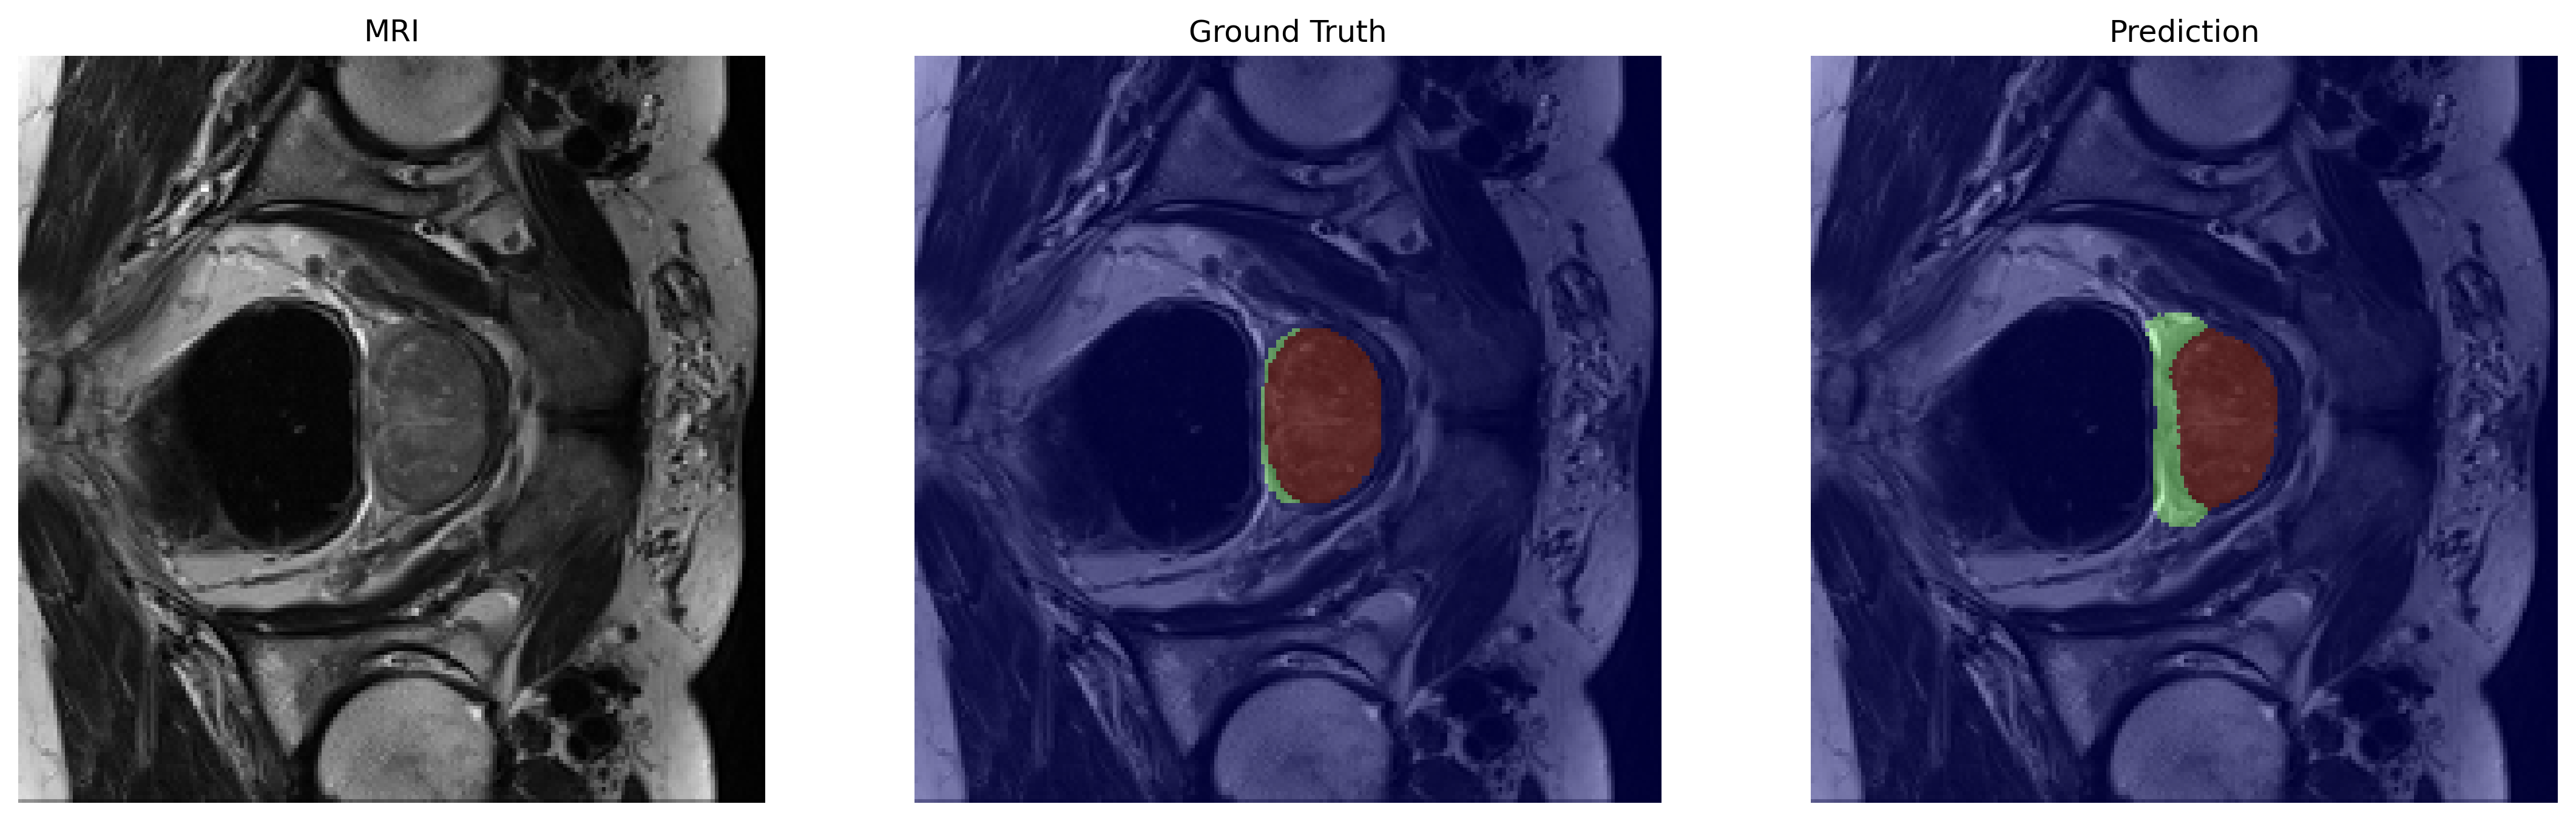

##  3D Prostate MRI Segmentation using MONAI and 3D U-Net

### This project focuses on voxel-wise prostate zonal segmentation using multi-modal MRI data (T2 + ADC) and a 3D U-Net architecture implemented with MONAI.

The segmentation task classifies each voxel into:

* Background
* Peripheral Zone (PZ)
* Transitional Zone (TZ)

The project demonstrates:

* Medical image preprocessing
* MONAI transform pipelines
* 3D volumetric segmentation
* Patch-based training
* Validation Dice evaluation
* Anatomical segmentation visualization

### Dataset

Dataset: Dataset005_Prostate

Contents:

* T2 MRI modality
* ADC MRI modality
* PZ/TZ segmentation masks

Dataset Structure:

* imagesTr/
* imagesTs/
* labelsTr/
* dataset.json

Labels:

Label	        *  Meaning
* 0	           -Background
* 1	           -PZ
* 2	           -TZ

### Model Architecture

Model Used:

* MONAI 3D U-Net

### Configuration:

### UNet(
    spatial_dims=3,
    in_channels=2,
    out_channels=3,
    channels=(16,32,64,128,256),
    strides=(2,2,2,2),
    num_res_units=2
)

### Input:

* T2 MRI
* ADC MRI

Output:

* Background segmentation
* PZ segmentation
*TZ segmentation

### Training Pipeline

Training Features:

* MONAI transforms
* RandCropByPosNegLabeld
* Patch-based training
* Sliding window inference
* Dice loss optimization
* Checkpoint saving

Training Strategy:

* Patch size: 128 × 128 × 16
* num_samples = 2
* Validation Dice monitoring
* Checkpoint continuation training

### Training Results

Best Validation Dice:

* 0.6094

Best Epoch:

* 136

Observations:

* The model successfully learned prostate anatomy.
* The prediction masks preserved the curved PZ/TZ anatomical relationship.
* Validation visualization showed meaningful prostate localization.
* Some validation cases still exhibited partial contour under-segmentation.
* Further refinement training may improve contour completeness.

### Validation Visualization

Insert your saved validation image below.

Example:

###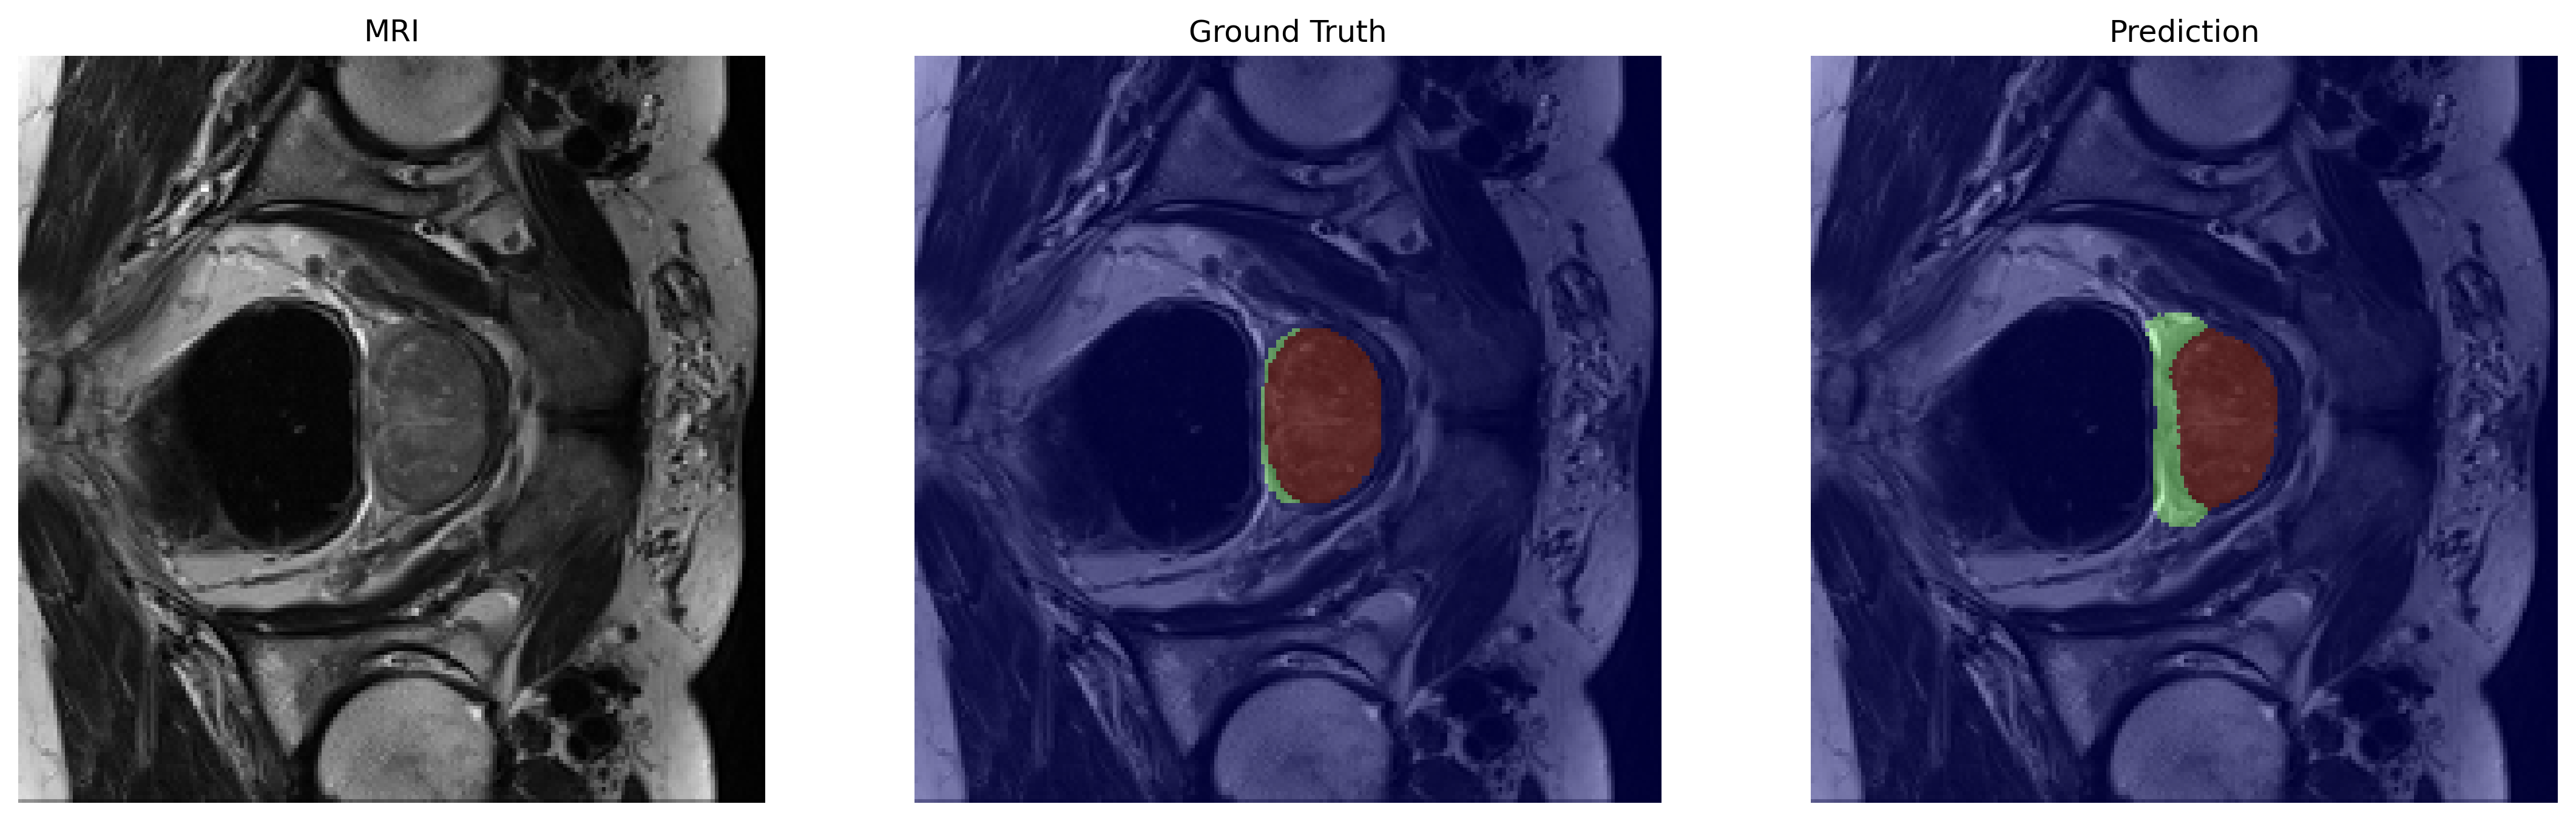

### Interpretation of Validation Output

The validation prediction demonstrated:

* Correct prostate localization
* Anatomically coherent segmentation
* Proper PZ/TZ spatial organization
* Curved PZ wrapping around TZ
* Partial contour under-segmentation in some regions

This suggests the model has learned volumetric anatomical structure but still requires additional refinement training for improved boundary precision.

### Technical Concepts Learned

This project involved:

* Voxel-wise segmentation
* 3D medical image processing
* Multi-modal MRI fusion
* MONAI workflows
* Patch-based volumetric training
* Dice evaluation metrics
* Sliding window inference
* Anatomical validation analysis

### Tools and Libraries
* Python
* PyTorch
* MONAI
* NumPy
* Matplotlib
* nibabel
* Google Colab

### Future Improvements

Possible next steps:

* Longer refinement training
* Lower learning rate fine-tuning
* Advanced augmentation
* Attention U-Net
* SwinUNETR
* Error map visualization
* Dice per class evaluation
* Full prostate contour refinement

### Conclusion

This project successfully implemented a 3D medical image segmentation pipeline for prostate zonal segmentation using MONAI and 3D U-Net.

The model demonstrated meaningful anatomical learning, volumetric segmentation capability, and clinically interpretable prostate zonal predictions.

The project also provided practical experience in:

* Medical AI workflows
* Volumetric deep learning
* Segmentation evaluation
* Anatomical interpretation of model predictions
* Cloud-based GPU training using Google Colab